# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from numpy import cross
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}
# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (cv_score.mean(), cv_score.std())
    

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [16]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(svm_pipe, cv=5, scoring='f1_macro', n_jobs=-1, param_grid=svm_param_grid)
svm_grid_search.fit(X_train, y_train)
svm_best_index = svm_grid_search.best_index_

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")
print(f"mean CV F1: {svm_grid_search.cv_results_['mean_test_score'][svm_best_index]:.4f} ± {svm_grid_search.cv_results_['std_test_score'][svm_best_index]:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786
mean CV F1: 0.9786 ± 0.0176


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_gs_res = pd.DataFrame(svm_grid_search.cv_results_, columns=['params', 'mean_test_score', 'std_test_score', 'rank_test_score'])
svm_gs_res.head(10)

,params,mean_test_score,std_test_score,rank_test_score
0,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.940340,0.020136,22
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
2,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.937500,0.014005,23
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
4,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.638684,0.043638,24
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
7,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.964626,0.014950,11
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10
9,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.964626,0.014950,11


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),     
    'max_depth': [randint(2, 20),None],
    'min_samples_split': randint(2, 20),  
    'max_features': ['sqrt', 'log2', 0.5],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_model = RandomForestClassifier()

rf_random_search = RandomizedSearchCV(rf_model, cv=5, param_distributions=rf_param_dist)
rf_random_search.fit(X_train, y_train)
rf_best_index = rf_random_search.best_index_

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")
print(f"mean CV F1: {rf_random_search.cv_results_['mean_test_score'][rf_best_index]:.4f} ± {rf_random_search.cv_results_['std_test_score'][rf_best_index]:.4f}")

mean CV F1: 0.9604 ± 0.0149
Лучшие параметры RF: {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 9, 'n_estimators': 162}
Лучший CV F1: 0.9604


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [19]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_best = rf_random_search.best_estimator_
rf_best_preds = rf_best.predict(X_test)

rf_base = base_models['RandomForest']
rf_base.fit(X_train, y_train)
rf_base_preds = rf_base.predict(X_test)

svm_best = svm_grid_search.best_estimator_
svm_best_preds = svm_best.predict(X_test)

svm_base = base_models['SVM']
svm_base.fit(X_train,y_train)
svm_base_preds = svm_base.predict(X_test)

print('SVM Baseline:')
print(classification_report(y_test, svm_base_preds))
print()

print('SVM Grid:')
print(classification_report(y_test, svm_best_preds))
print()

print('RF Baseline:')
print(classification_report(y_test, rf_base_preds))
print()

print('RF Grid:')
print(classification_report(y_test, rf_best_preds))
print()

print('RF Baseline:')
print(classification_report(y_test, rf_base_preds))
print()

print('RF Grid:')
print(classification_report(y_test, rf_best_preds))
print()



# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |  0.9694 ± 0.0193 |   0.98  |
# | SVM Grid Search       |  0.9786 ± 0.0176 |   0.98  |
# | RF baseline           |  0.9504 ± 0.0255 |   0.95  |
# | RF Random Search      |  0.9604 ± 0.0149 |   0.95  |

SVM Baseline:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


SVM Grid:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


RF Baseline:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96  

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

<Axes: xlabel='importance', ylabel='feature'>

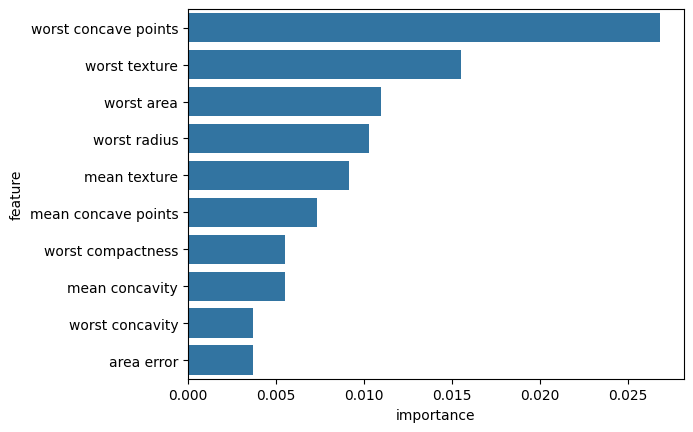

In [27]:
from sklearn.inspection import permutation_importance
import seaborn as sb

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': pi_result.importances_mean
}).sort_values(by='importance', ascending=False)
# Построим bar plot топ-10 признаков
sb.barplot(importance_df.head(10), x='importance', y='feature')
# YOUR CODE HERE

top-5 (rf MDI):
                 feature  importance
22       worst perimeter    0.240252
27  worst concave points    0.223515
20          worst radius    0.166654
23            worst area    0.123770
7    mean concave points    0.076837

top-5: Permutation Importance (test):
                 feature  importance
27  worst concave points    0.026846
21         worst texture    0.015527
23            worst area    0.010970
20          worst radius    0.010278
1           mean texture    0.009161


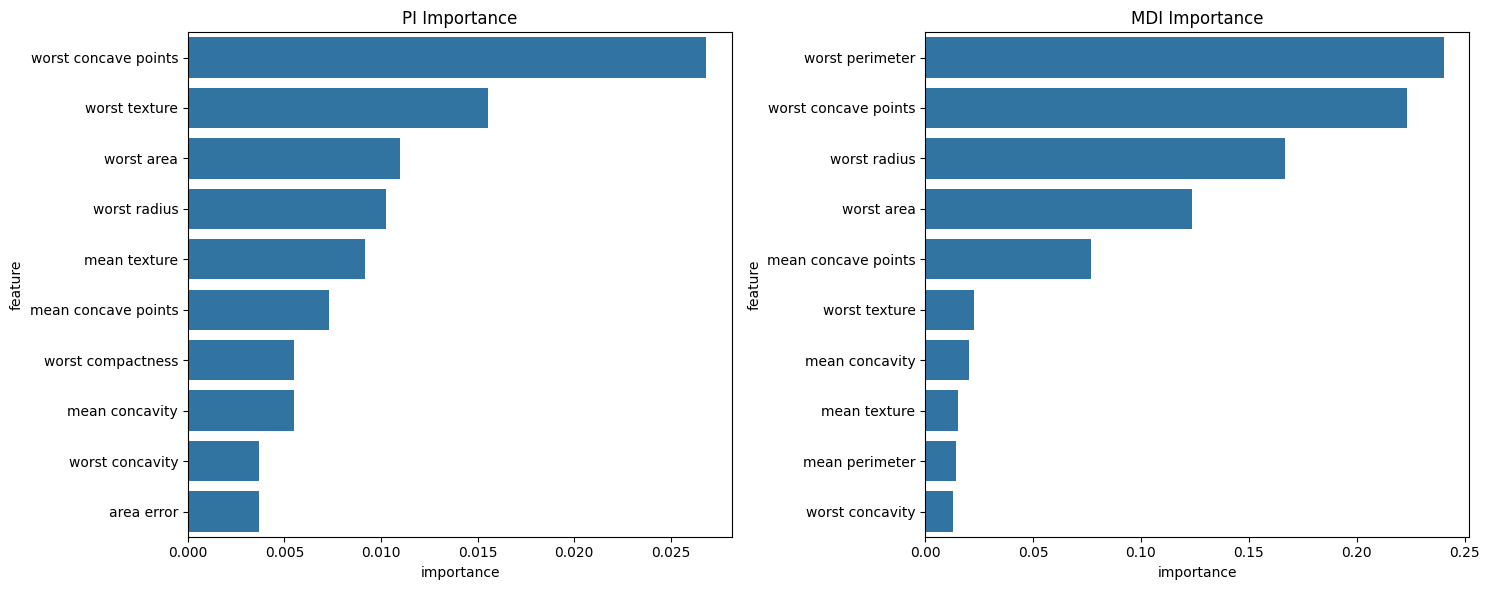

In [66]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║     - не совпадает                                           ║
# ║  Если нет — как вы это объясняете?                           ║
# ║      - mdi считает насколько изменилась ошибка               ║
# ║          после сплита с этим признаком, а PI считает реальное║
# ║          падение метрики на тестовой выборке.                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("top-5 (rf MDI):")
print(rf_importance.head(5))
print("\ntop-5: Permutation Importance (test):")
print(importance_df.head(5))

# 3. Визуализация для наглядности
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sb.barplot(importance_df.head(10), x='importance', y='feature', ax=ax[0])
ax[0].set_title('PI Importance')
sb.barplot(rf_importance.head(10), x='importance', y='feature',ax=ax[1])
ax[1].set_title('MDI Importance')
plt.tight_layout()
plt.show()


# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?
#   - низкий MDI, высокий PI значит, что признак довольно уникален (редко использовался при разбиении), но важен.
#   - Высокий MDI, низкий PI означает, что модель решает при обучении опираться на этот признак, но на самом деле он не так важен. Это переобучение.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

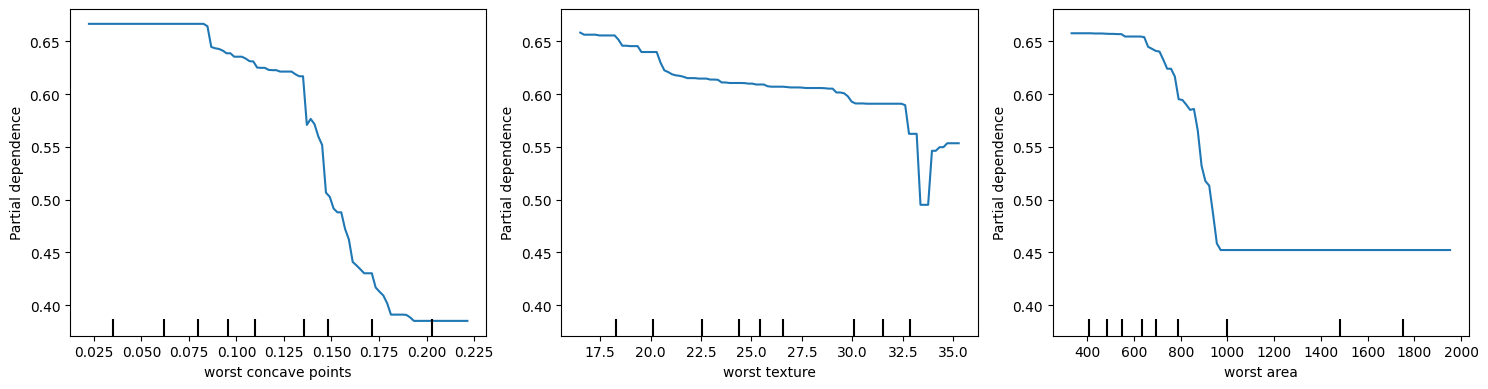

In [37]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = importance_df.head(3).index

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(rf_best, X=X_test, features=top3_idx, ax=ax)

plt.tight_layout()
plt.show()

ICE-line for: 27    worst concave points
Name: feature, dtype: str


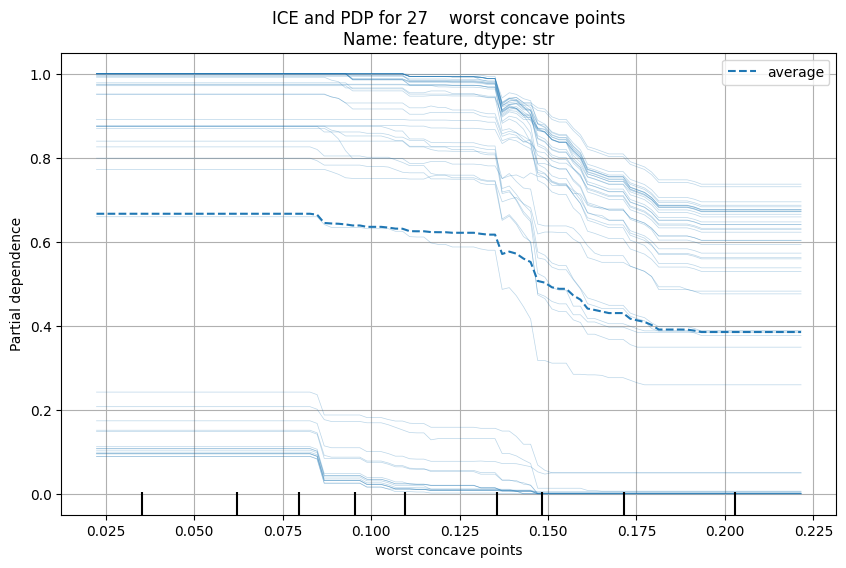

In [45]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
most_important_feature = importance_df.head(1)['feature']
print(f"ICE-line for: {most_important_feature}")

fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    best_rf, 
    X_test, 
    features=[most_important_feature],
    kind='both',
    ax=ax,
    subsample=50,
    random_state=42
)

ax.set_title(f'ICE and PDP for {most_important_feature}')
plt.grid(True)
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [62]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print(f"shape of SHAP values: {shap_values.shape}")    

shape of SHAP values: (114, 30, 2)


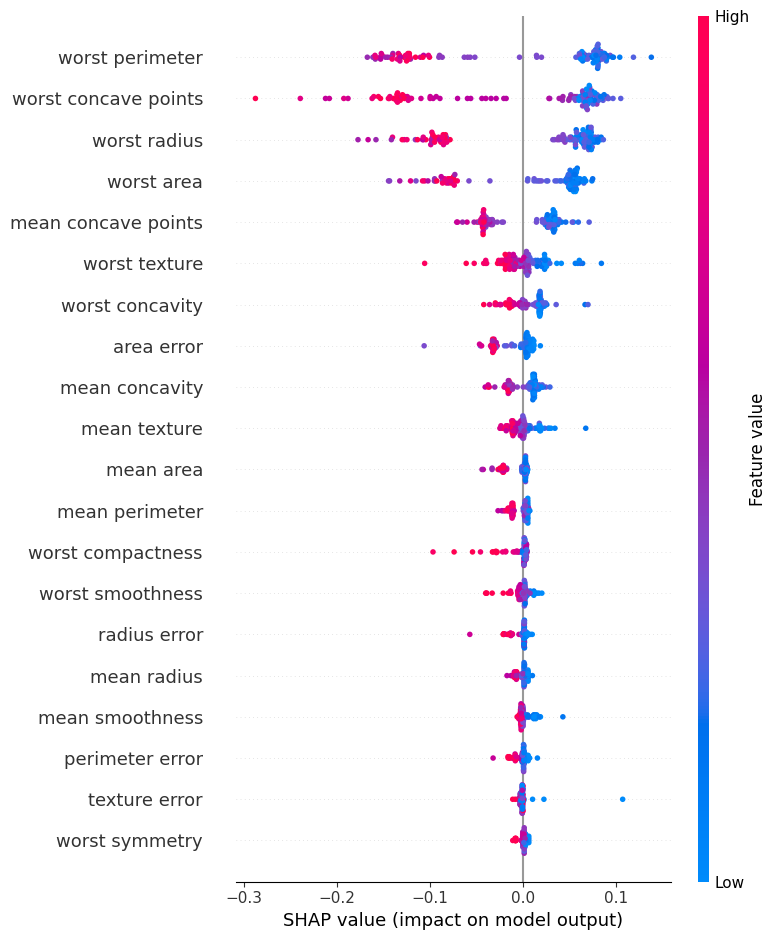

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║     - worst perimeter, worst concave points, worst radius    ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ║     - не совсем, тк тут есть мультиколлинеарность, например  ║
# ║        worst perimeter и worst radius. PI занижает такие фичи║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap.summary_plot(shap_values[:, :, 1], X_test)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ║     - worst radius, worst perimeter, worst area, те, которые ║
# ║           синие                                              ║
# ╚══════════════════════════════════════════════════════════════╝

shap.initjs()

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

idx = errors[0]

# YOUR CODE HERE
shap.force_plot(
    explainer.expected_value[1], 
    shap_values[idx, :, 1], 
    X_test.iloc[idx, :]
)

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [70]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║       - PI покажет аномально высокое значение для            ║
# ║         leaky_feature (близкое к 1.0 или максимально         ║
# ║                                          возможному вкладу)  ║
# ║        так как этот признак напрямую или почти напрямую      ║
# ║                          коррелирует с целевой переменной.   ║
# ║        метрика выросла, тк модель уже "запомнила" пример.    ║
# ║                                                              ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║      - На summary plot признак leaky_feature будет           ║
# ║       находиться на самой верхней строчке с огромным отрывом ║
# ║       по ширине распределения SHAP-значений                  ║
# ║                                                              ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ║       В PI важность random_feature будет близка к нулю       ║
# ║         или даже отрицательна                                ║
# ║                                                              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ext.fit(X_train_ext, y_train)

pi_ext = permutation_importance(rf_ext, X_test_ext, y_test, n_repeats=10, random_state=42, n_jobs=-1)

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Модель                | CV F1 (mean±std) | Test F1 | Выводы              
# ║  |-----------------------|------------------|---------|---------------------
# ║  | SVM baseline          |  0.9694 ± 0.0193 |   0.98  |  хорошая база       
# ║  | SVM Grid Search       |  0.9786 ± 0.0176 |   0.98  |  метрика чуть подросла и разброс стал меньше  
# ║  | RF baseline           |  0.9504 ± 0.0255 |   0.95  |  тоже хорошая база
# ║  | RF Random Search      |  0.9604 ± 0.0149 |   0.95  |  метрика почти не выросла, а разброс стал меньше, но все еще хуже, чем svm                     
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

> 1. тюнинг незначительно повлиял на саму метрику, но довольно сильно уменьшил разброс моделей

> 2. не совсем совпадают из-за того, что многие из них мультиколлинеарны, поэтому PI урезает их ценность.

> 3. модель бы выучила смещения из обучающей выборки, и кросс-валидация была бы уже необъективной

> 4. PI - для отбора признаков, SHAP - для объяснения логики модели

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")